# Test, métriques, courbes consolidées et Grad-CAM

Ce notebook charge le modèle entraîné puis produit :

- évaluation sur le jeu de test
- `classification_report`
- matrice de confusion
- exemples de prédictions
- visualisation **Grad-CAM** pour montrer **où le modèle regarde**

Important :
- le modèle reste un **classifieur**
- Grad-CAM donne une **zone d'attention**
- ce n'est pas une segmentation précise pixel par pixel

In [50]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from PIL import Image
import matplotlib.cm as cm

PROJECT_DIR = Path.cwd()
SPLIT_DIR = PROJECT_DIR / "data" / "split"
TEST_DIR = SPLIT_DIR / "test"
MODELS_DIR = PROJECT_DIR / "models"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
REPORTS_DIR = OUTPUTS_DIR / "reports"

IMG_SIZE = 224
BATCH = 32

MODEL_PATH = MODELS_DIR / "plantvillage_final.keras"
CLASS_INDICES_PATH = PROJECT_DIR / "class_indices.json"

print("MODEL_PATH exists:", MODEL_PATH.exists())
print("CLASS_INDICES_PATH exists:", CLASS_INDICES_PATH.exists())
print("TEST_DIR exists:", TEST_DIR.exists())

MODEL_PATH exists: True
CLASS_INDICES_PATH exists: True
TEST_DIR exists: True


## 1. Chargement du modèle et des classes

In [51]:
model = tf.keras.models.load_model(MODEL_PATH)

with open(CLASS_INDICES_PATH, "r", encoding="utf-8") as f:
    class_indices = json.load(f)

idx_to_class = {v: k for k, v in class_indices.items()}
print("Nb classes:", len(class_indices))
print("Quelques classes:", list(class_indices.items())[:5])

Nb classes: 15
Quelques classes: [('Pepper__bell___Bacterial_spot', 0), ('Pepper__bell___healthy', 1), ('Potato___Early_blight', 2), ('Potato___Late_blight', 3), ('Potato___healthy', 4)]


## 2. Générateur de test

In [52]:
test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    str(TEST_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

print("Test samples:", test_gen.samples)

Found 3094 images belonging to 15 classes.
Test samples: 3094


## 3. Évaluation quantitative

In [53]:
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

y_true = test_gen.classes
y_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

labels = [k for k, _ in sorted(class_indices.items(), key=lambda x: x[1])]
report_dict = classification_report(y_true, y_pred, target_names=labels, output_dict=True, digits=4)
report_text = classification_report(y_true, y_pred, target_names=labels, digits=4)

print(report_text)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(REPORTS_DIR / "classification_report.csv", encoding="utf-8")
with open(REPORTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

display(report_df.head())

97/97 ━━━━━━━━━━━━━━━━━━━━ 45s 435ms/step - accuracy: 0.9606 - loss: 0.1218
Test loss: 0.1218019351363182
Test accuracy: 0.9605688452720642
97/97 ━━━━━━━━━━━━━━━━━━━━ 48s 478ms/step
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     1.0000    0.9867    0.9933       150
                     Pepper__bell___healthy     0.9955    1.0000    0.9978       223
                      Potato___Early_blight     0.9868    0.9933    0.9900       150
                       Potato___Late_blight     0.9800    0.9800    0.9800       150
                           Potato___healthy     0.8889    1.0000    0.9412        24
                      Tomato_Bacterial_spot     0.9377    0.9875    0.9619       320
                        Tomato_Early_blight     0.9267    0.9267    0.9267       150
                         Tomato_Late_blight     0.9813    0.9564    0.9687       275
                           Tomato_Leaf_Mold     0.96

,precision,recall,f1-score,support
Pepper__bell___Bacterial_spot,1.000000,0.986667,0.993289,150.0
Pepper__bell___healthy,0.995536,1.000000,0.997763,223.0
Potato___Early_blight,0.986755,0.993333,0.990033,150.0
Potato___Late_blight,0.980000,0.980000,0.980000,150.0
Potato___healthy,0.888889,1.000000,0.941176,24.0


## 4. Matrice de confusion

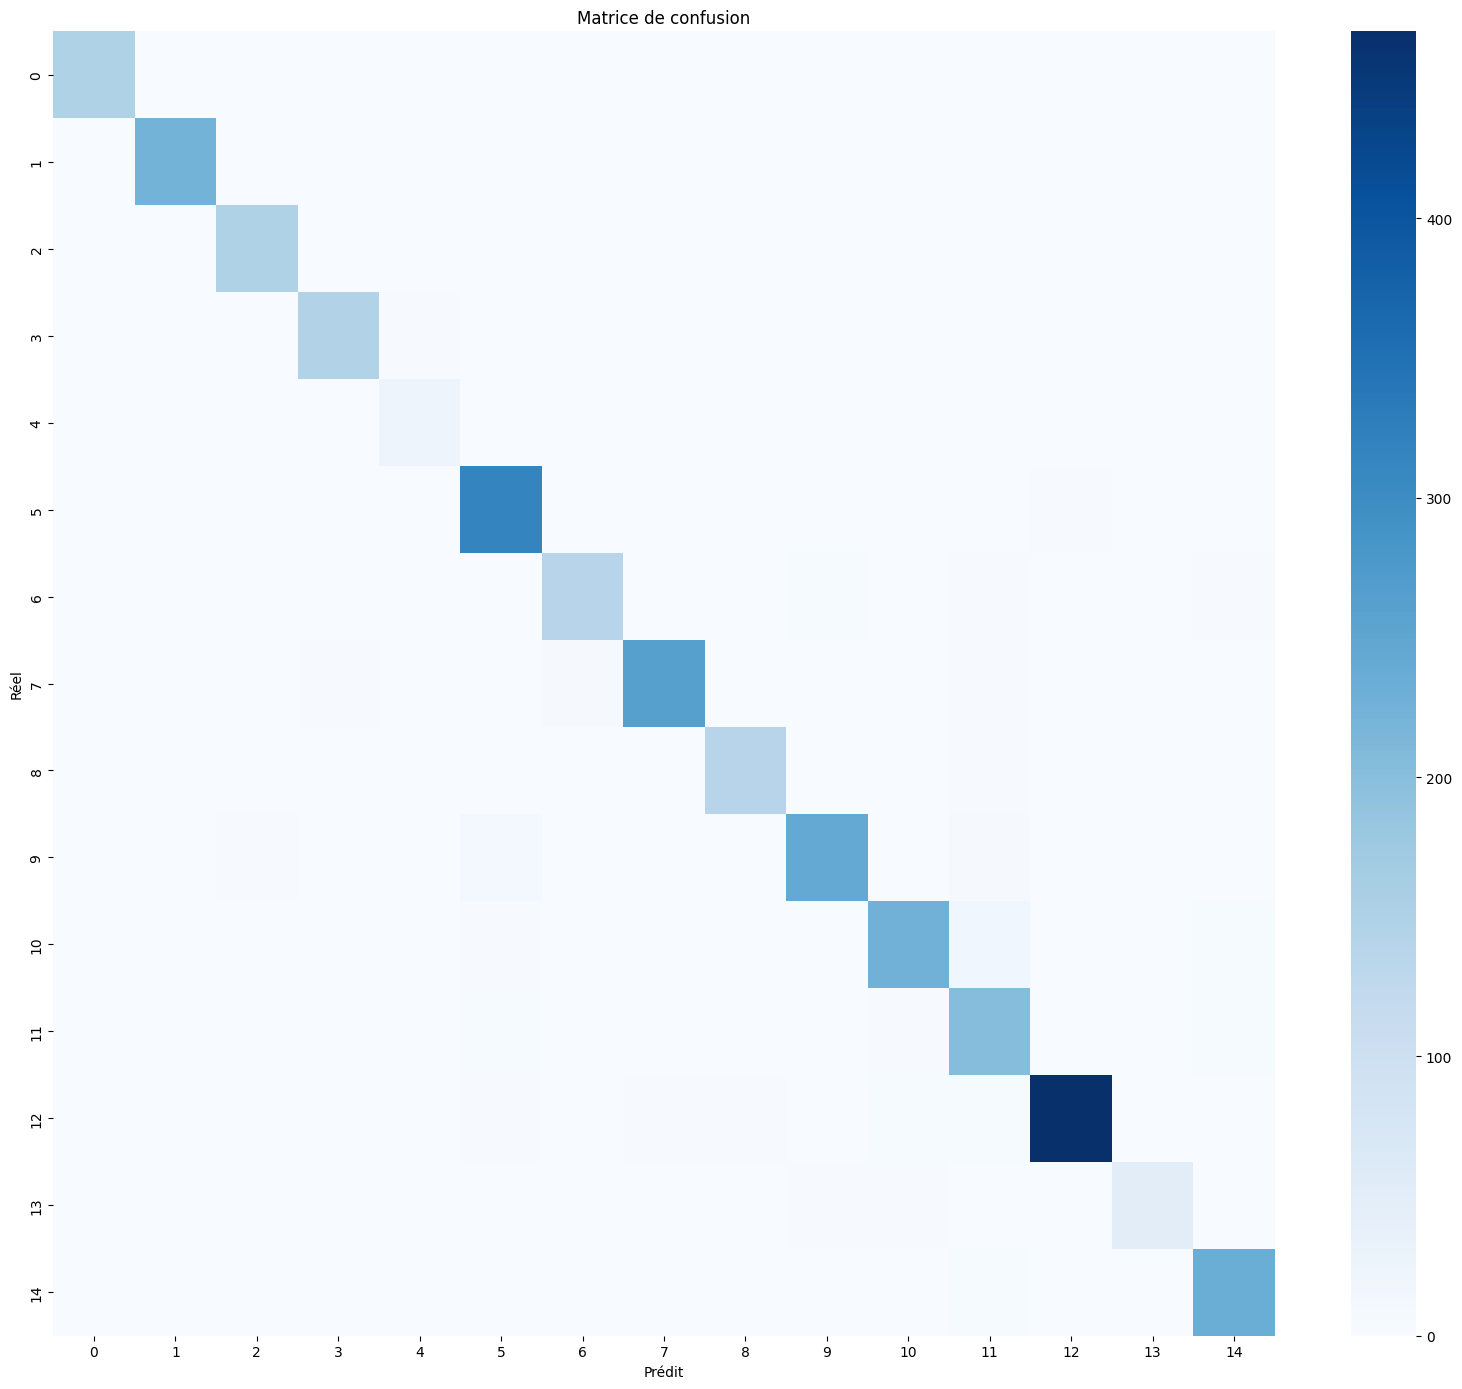

In [54]:
cmatrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cmatrix, annot=False, cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## 5. Lecture rapide des classes les plus confondues

In [55]:
cm_no_diag = cmatrix.copy()
np.fill_diagonal(cm_no_diag, 0)

top_confusions = []
for i in range(cm_no_diag.shape[0]):
    for j in range(cm_no_diag.shape[1]):
        if cm_no_diag[i, j] > 0:
            top_confusions.append({
                "true_class": idx_to_class[i],
                "pred_class": idx_to_class[j],
                "count": int(cm_no_diag[i, j])
            })

top_confusions_df = pd.DataFrame(top_confusions).sort_values("count", ascending=False).head(20)
top_confusions_df.to_csv(REPORTS_DIR / "top_confusions.csv", index=False, encoding="utf-8")
display(top_confusions_df)

,true_class,pred_class,count
28,Tomato_Spider_mites_Two_spotted_spider_mite,Tomato__Target_Spot,18
20,Tomato_Septoria_leaf_spot,Tomato_Bacterial_spot,10
24,Tomato_Septoria_leaf_spot,Tomato__Target_Spot,7
13,Tomato_Late_blight,Tomato_Early_blight,6
30,Tomato__Target_Spot,Tomato_Bacterial_spot,5
29,Tomato_Spider_mites_Two_spotted_spider_mite,Tomato_healthy,4
32,Tomato__Target_Spot,Tomato_healthy,4
37,Tomato__Tomato_YellowLeaf__Curl_Virus,Tomato__Target_Spot,4
9,Tomato_Early_blight,Tomato_Septoria_leaf_spot,4
36,Tomato__Tomato_YellowLeaf__Curl_Virus,Tomato_Spider_mites_Two_spotted_spider_mite,4


## 6. Exemples de prédictions

On affiche quelques images du jeu de test avec :

- classe réelle
- classe prédite
- confiance

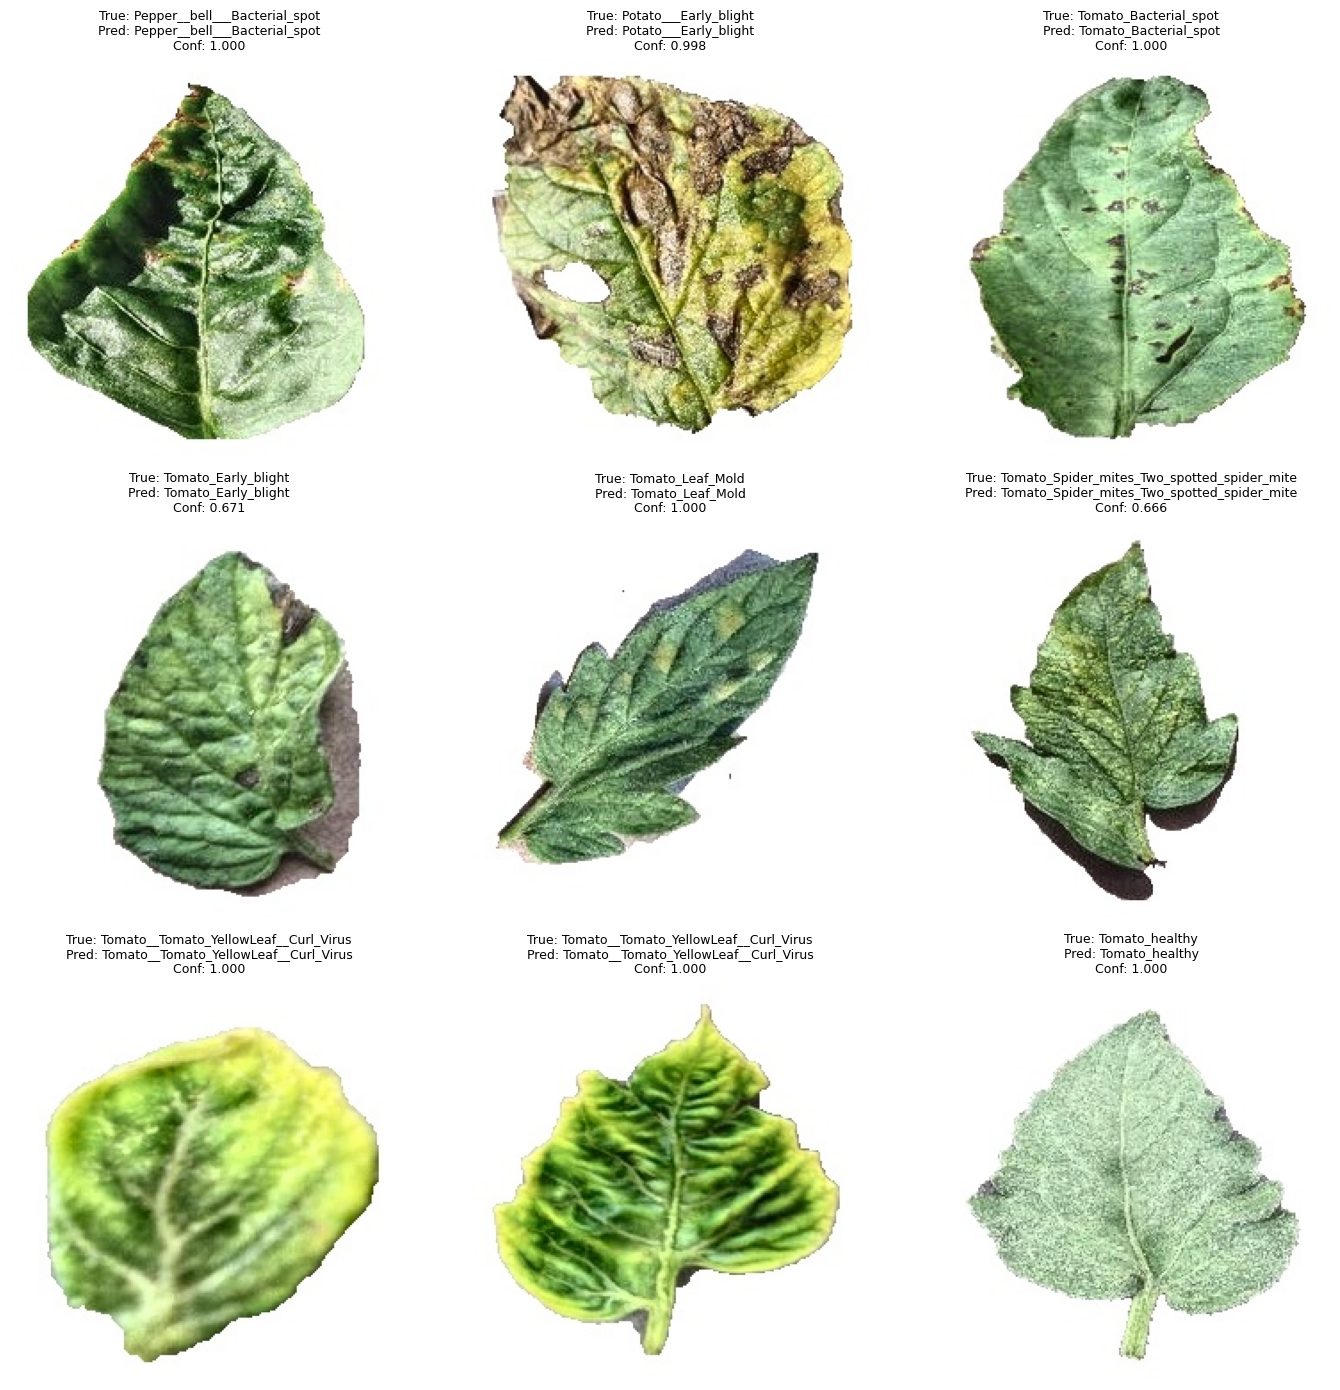

In [56]:
test_filepaths = [Path(TEST_DIR) / rel_path for rel_path in test_gen.filenames]

def load_image_for_display(img_path, size=(224, 224)):
    img = Image.open(img_path).convert("RGB").resize(size)
    return np.array(img)

sample_indices = np.linspace(0, len(test_filepaths)-1, num=min(9, len(test_filepaths)), dtype=int)

plt.figure(figsize=(14, 14))
for plot_idx, idx in enumerate(sample_indices, start=1):
    img = load_image_for_display(test_filepaths[idx], (IMG_SIZE, IMG_SIZE))
    pred_idx = y_pred[idx]
    true_idx = y_true[idx]
    conf = float(np.max(y_prob[idx]))

    plt.subplot(3, 3, plot_idx)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"True: {idx_to_class[true_idx]}\nPred: {idx_to_class[pred_idx]}\nConf: {conf:.3f}",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "prediction_examples.png", dpi=150)
plt.show()

## 7. Grad-CAM : visualiser la zone d'attention

Ici, le but est de montrer **comment le modèle prend sa décision**.

Important :
- cela montre une **région importante**
- cela ne remplace pas une vraie segmentation
- la heatmap reste une interprétation

Dernière couche conv utilisée pour Grad-CAM: top_conv


In [64]:
last_conv_layer_name = "top_conv"
print("Dernière couche conv utilisée pour Grad-CAM:", last_conv_layer_name)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv", pred_index=None):
    # Trouver le backbone
    backbone = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            backbone = layer
            break

    if backbone is None:
        raise ValueError("Backbone introuvable dans le modèle.")

    # Couche cible dans le backbone
    try:
        last_conv_layer = backbone.get_layer(last_conv_layer_name)
    except Exception:
        raise ValueError(f"Couche '{last_conv_layer_name}' introuvable dans le backbone.")

    # Modèle: image -> [sortie top_conv, sortie backbone]
    backbone_grad_model = tf.keras.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output]
    )

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, backbone_out = backbone_grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)

        # passer ensuite dans la tête du modèle principal
        x = backbone_out
        passed_backbone = False
        for layer in model.layers:
            if layer == backbone:
                passed_backbone = True
                continue
            if passed_backbone:
                x = layer(x, training=False)

        preds = x

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    if grads is None:
        raise ValueError("Gradient nul. Vérifie la connexion entre backbone et tête du modèle.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())

    return heatmap.numpy(), int(pred_index)

import numpy as np
from PIL import Image
import matplotlib.cm as cm
import cv2
import tensorflow as tf

def overlay_gradcam(img_path, heatmap, alpha=0.55, threshold=0.6, draw_contours=True):
    # image originale
    img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img, dtype=np.uint8)

    # heatmap [0,1]
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # redimensionner la heatmap à la taille de l'image
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # renforcer le contraste
    heatmap_strong = np.power(heatmap_resized, 0.5)  # <1 => zones chaudes plus visibles

    # seuillage : garder uniquement les zones importantes
    mask = heatmap_strong >= threshold

    # colormap plus visible
    heatmap_uint8 = np.uint8(255 * heatmap_strong)
    color_map = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    color_map = cv2.cvtColor(color_map, cv2.COLOR_BGR2RGB)

    # overlay seulement sur les zones fortes
    overlay = img.copy().astype(np.float32)
    overlay[mask] = (1 - alpha) * overlay[mask] + alpha * color_map[mask]

    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    # contours
    if draw_contours:
        mask_uint8 = (mask.astype(np.uint8) * 255)
        contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)  # rouge

    return Image.fromarray(overlay)

Dernière couche conv utilisée pour Grad-CAM: top_conv


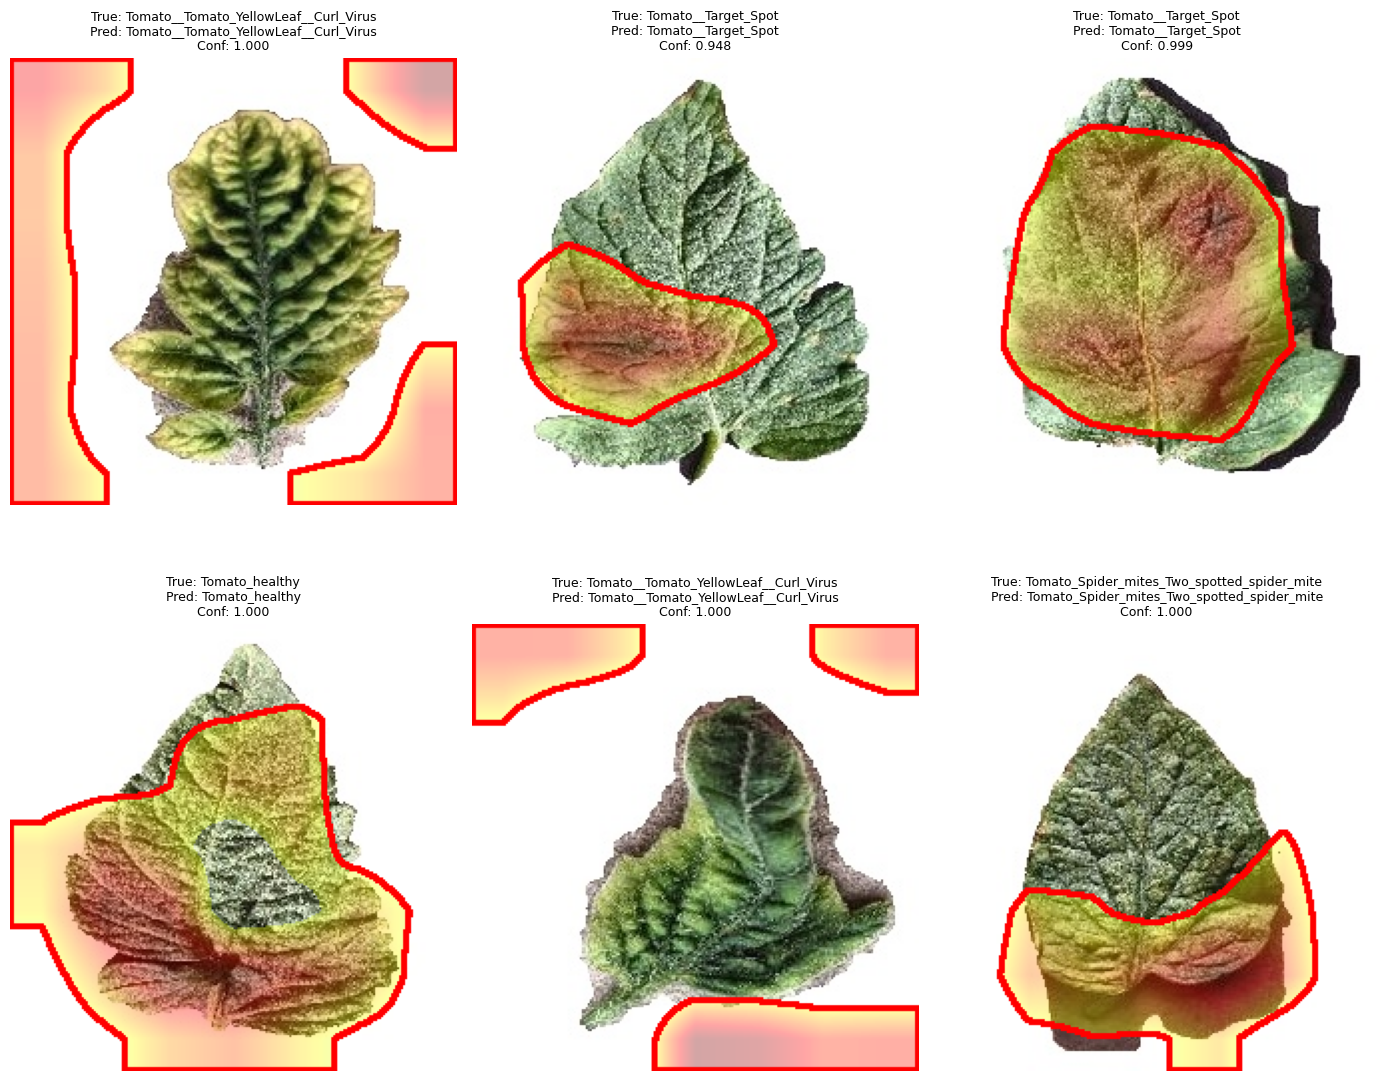

In [68]:
# On prend quelques exemples bien répartis dans le test
np.random.seed(42)
gradcam_indices = np.random.choice(
    len(test_filepaths),
    size=min(6, len(test_filepaths)),
    replace=False
)
plt.figure(figsize=(14, 12))
for plot_idx, idx in enumerate(gradcam_indices, start=1):
    img_path = test_filepaths[idx]
    img_array = get_img_array(str(img_path), size=(IMG_SIZE, IMG_SIZE))

    heatmap, pred_idx = make_gradcam_heatmap(
        img_array=img_array,
        model=model,
        last_conv_layer_name=last_conv_layer_name
    )

    overlay = overlay_gradcam(str(img_path), heatmap, alpha=0.35)
    true_idx = y_true[idx]
    conf = float(np.max(y_prob[idx]))

    plt.subplot(2, 3, plot_idx)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(
        f"True: {idx_to_class[true_idx]}\nPred: {idx_to_class[pred_idx]}\nConf: {conf:.3f}",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "gradcam_examples.png", dpi=150)
plt.show()

## 8. Comment commenter les résultats dans le rapport

### Ce que montrent les métriques
- `accuracy` donne une vue globale
- le `classification_report` montre précision, rappel, F1 par classe
- la matrice de confusion montre quelles classes se ressemblent le plus

### Ce que montre Grad-CAM
- les zones colorées sont les régions qui ont le plus contribué à la prédiction
- si la heatmap tombe sur les taches / lésions, cela renforce l'interprétation
- si elle tombe surtout sur le fond, la feuille entière ou des bords non pertinents, la décision est moins rassurante

### Limite à écrire clairement
Le modèle reste un modèle de **classification**.  
La visualisation Grad-CAM fournit une **localisation approximative** de l'attention du réseau, mais pas une segmentation exacte de la zone malade.